# Text2SQL - Query Decomposition

복잡한 질문을 **서브 질문으로 분해**하여 Text2SQL 정확도를 높이는 기법을 학습합니다.

1. 복잡한 자연어 질문이 단일 SQL로 처리되기 어려운 이유 이해
2. **Query Decomposition** 기법으로 서브 질문 분해 및 개별 처리
3. 분해 전략(compare, aggregate, sequential) 구분 및 적용
4. LangGraph 기반 **분해-실행-종합** 파이프라인 구축
5. Few-Shot(005)과 결합한 통합 파이프라인 구현

> 참고자료: [DIN-SQL](https://arxiv.org/abs/2304.11015) - Decomposed In-Context Learning for Text2SQL

---

## 환경 설정 및 준비

`(1) Env 환경변수`

In [25]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [26]:
import os
from pprint import pprint
import json

import warnings
warnings.filterwarnings('ignore')

`(3) SQLite DB`

In [27]:
from langchain_community.utilities import SQLDatabase
import ast

db = SQLDatabase.from_uri("sqlite:///etf_database.db", ignore_tables=["ETFsInfo"])
print(db.dialect)
print(db.get_usable_table_names())
print(db.get_table_info()[:500])

sqlite
['ETFs']

CREATE TABLE "ETFs" (
	"종목코드" TEXT, 
	"종목명" TEXT, 
	"상장일" TEXT, 
	"분류체계" TEXT, 
	"운용사" TEXT, 
	"수익률_최근1년" REAL, 
	"기초지수" TEXT, 
	"추적오차" REAL, 
	"순자산총액" REAL, 
	"괴리율" REAL, 
	"변동성" TEXT, 
	"복제방법" TEXT, 
	"총보수" REAL, 
	"과세유형" TEXT, 
	PRIMARY KEY ("종목코드")
)

/*
3 rows from ETFs table:
종목코드	종목명	상장일	분류체계	운용사	수익률_최근1년	기초지수	추적오차	순자산총액	괴리율	변동성	복제방법	총보수	과세유형
466400	1Q 25-08 회사채(A+이상)액티브	2023/09/19	채권-회사채-단기	하나자산운용	4.52	KIS 2025-08만기형 크레딧 A+이상 지수(총수익)	0.11	111916276404.0	0.03	매우낮음	실물(액티브)	0.1	배당소득세(보유기간과


`(4) 기본 컴포넌트 준비`

In [28]:
from typing import TypedDict, Annotated, List
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import QuerySQLDatabaseTool
from langchain_core.vectorstores import InMemoryVectorStore
from langgraph.graph import START, END, StateGraph
from IPython.display import Image, display

# LLM 모델 생성
llm = ChatOpenAI(model="gpt-4.1-mini")

# 임베딩 모델
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")

---

## 1. 기본 SQL Chain 준비 

004에서 구현한 Entity Matching 기반 Chain을 재사용합니다.  
이 Chain은 고유명사 벡터 스토어를 활용하여 운용사/종목명을 정확히 매칭합니다.

In [29]:
import re

# 고유명사 추출 
def query_as_list(db, query):
    res = db.run(query)
    res = [el for sub in ast.literal_eval(res) for el in sub if el]
    res = [re.sub(r"\b\d+\b", "", string).strip() for string in res]
    return list(set(res))

etfs = query_as_list(db, "SELECT DISTINCT 종목명 FROM ETFs")
fund_managers = query_as_list(db, "SELECT DISTINCT 운용사 FROM ETFs")
print(f"ETF 종목 수: {len(etfs)}, 운용사 수: {len(fund_managers)}")

# 엔티티 벡터 스토어
entity_store = InMemoryVectorStore(embeddings)
_ = entity_store.add_texts(etfs + fund_managers)
entity_retriever = entity_store.as_retriever(search_kwargs={"k": 10})

ETF 종목 수: 925, 운용사 수: 26


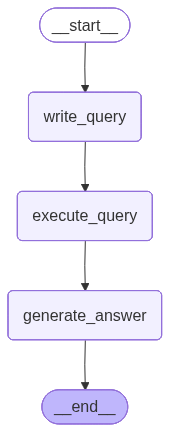

In [30]:
from langchain_core.tools import tool
from pydantic import BaseModel, Field

@tool("search_proper_nouns")
def entity_retriever_tool(query: str) -> str:
    """
    Use to look up values to filter on. Input is an approximate spelling 
    of the proper noun, output is valid proper nouns. Use the noun most 
    similar to the search.
    """
    docs = entity_retriever.invoke(query)
    return "\n\n".join([doc.page_content for doc in docs])

# 기본 State
class State(TypedDict):
    question: str
    query: str
    result: str
    answer: str

class QueryOutput(BaseModel):
    """Generated SQL query."""
    query: str = Field(description="Syntactically valid SQL query.")

# SQL 생성 프롬프트
query_prompt_template = ChatPromptTemplate.from_template("""
Given an input question, create a syntactically correct {dialect} query to run to help find the answer.
Unless the user specifies a specific number, always limit to at most {top_k} results.
Order by relevant columns. Only ask for relevant columns.
Pay attention to column names in the schema. Be careful not to query non-existent columns.

Only use the following tables:
{table_info}

Entity names to consider:
{entity_info}

Question: {input}
""")

def write_query(state: State):
    """SQL 쿼리 생성 (엔티티 매칭)"""
    prompt = query_prompt_template.invoke({
        "dialect": db.dialect,
        "top_k": 10,
        "table_info": db.get_table_info(),
        "entity_info": entity_retriever_tool.invoke(state["question"]),
        "input": state["question"],
    })
    structured_llm = llm.with_structured_output(QueryOutput, method="function_calling")
    result = structured_llm.invoke(prompt)
    return {"query": result.query}

def execute_query(state: State):
    """SQL 쿼리 실행"""
    try:
        tool = QuerySQLDatabaseTool(db=db)
        return {"result": tool.invoke(state["query"])}
    except Exception as e:
        return {"result": f"쿼리 실행 중 오류 발생: {str(e)}"}

def generate_answer(state: State):
    """답변 생성"""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

# 기본 그래프
basic_graph = StateGraph(State)
basic_graph.add_node("write_query", write_query)
basic_graph.add_node("execute_query", execute_query)
basic_graph.add_node("generate_answer", generate_answer)
basic_graph.add_edge(START, "write_query")
basic_graph.add_edge("write_query", "execute_query")
basic_graph.add_edge("execute_query", "generate_answer")
basic_chain = basic_graph.compile()

display(Image(basic_chain.get_graph().draw_mermaid_png()))

### 1.1 Few-Shot 예시 벡터 스토어 준비

005에서 구축한 동적 Few-Shot 예시 시스템을 재사용합니다.  
Decomposition에서 각 서브 질문을 처리할 때 Few-Shot 예시를 활용하면 SQL 생성 정확도가 높아집니다.

In [31]:
from langchain_core.documents import Document

# Few-Shot 예시 데이터셋
examples = [
    {"question": "ETF 총 개수는?", "sql": "SELECT COUNT(*) FROM ETFs", "category": "count"},
    {"question": "총보수가 0.1% 이하인 ETF는?", "sql": "SELECT 종목명, 총보수 FROM ETFs WHERE 총보수 <= 0.1 ORDER BY 총보수 ASC LIMIT 10", "category": "filter"},
    {"question": "순자산총액이 가장 큰 ETF는?", "sql": "SELECT 종목명, 순자산총액 FROM ETFs ORDER BY 순자산총액 DESC LIMIT 1", "category": "sort"},
    {"question": "운용사별 ETF 개수는?", "sql": "SELECT 운용사, COUNT(*) as cnt FROM ETFs GROUP BY 운용사 ORDER BY cnt DESC LIMIT 10", "category": "aggregation"},
    {"question": "평균 수익률이 가장 높은 분류체계는?", "sql": "SELECT 분류체계, AVG(수익률_최근1년) as avg_ret FROM ETFs GROUP BY 분류체계 ORDER BY avg_ret DESC LIMIT 5", "category": "aggregation"},
    {"question": "운용사별 평균 총보수를 비교해주세요", "sql": "SELECT 운용사, AVG(총보수) as avg_fee FROM ETFs GROUP BY 운용사 ORDER BY avg_fee ASC LIMIT 10", "category": "aggregation"},
    {"question": "KB자산운용의 ETF 중 수익률 상위 5개는?", "sql": "SELECT 종목명, 수익률_최근1년 FROM ETFs WHERE 운용사 = 'KB자산운용' ORDER BY 수익률_최근1년 DESC LIMIT 5", "category": "filter_sort"},
    {"question": "삼성자산운용의 ETF 수는?", "sql": "SELECT COUNT(*) FROM ETFs WHERE 운용사 = '삼성자산운용'", "category": "filter_count"},
    {"question": "순자산 1000억 이상이고 총보수 0.3% 이하인 ETF는?", "sql": "SELECT 종목명, 순자산총액, 총보수 FROM ETFs WHERE 순자산총액 >= 100000000000 AND 총보수 <= 0.3 ORDER BY 순자산총액 DESC LIMIT 10", "category": "complex"},
    {"question": "수익률이 양수이고 변동성이 낮은 ETF를 추천해주세요", "sql": "SELECT 종목명, 수익률_최근1년, 변동성 FROM ETFs WHERE 수익률_최근1년 > 0 AND 변동성 = '매우낮음' ORDER BY 수익률_최근1년 DESC LIMIT 10", "category": "complex"},
    {"question": "분류체계별 ETF 개수를 비교해주세요", "sql": "SELECT 분류체계, COUNT(*) as cnt FROM ETFs GROUP BY 분류체계 ORDER BY cnt DESC", "category": "comparison"},
    {"question": "복제방법별 평균 추적오차는?", "sql": "SELECT 복제방법, AVG(추적오차) as avg_error FROM ETFs GROUP BY 복제방법 ORDER BY avg_error ASC", "category": "comparison"},
    {"question": "수익률 상위 10% ETF의 평균 총보수는?", "sql": "SELECT AVG(총보수) as avg_fee FROM (SELECT 총보수 FROM ETFs ORDER BY 수익률_최근1년 DESC LIMIT (SELECT COUNT(*) / 10 FROM ETFs))", "category": "advanced"},
]

# 벡터 스토어에 저장
example_docs = [
    Document(page_content=ex["question"], metadata={"sql": ex["sql"], "category": ex["category"]})
    for ex in examples
]
example_store = InMemoryVectorStore(embeddings)
_ = example_store.add_documents(example_docs)
example_retriever = example_store.as_retriever(search_kwargs={"k": 3})

print(f"Few-Shot 예시 벡터 스토어 구축 완료: {len(example_docs)}개")

Few-Shot 예시 벡터 스토어 구축 완료: 13개


In [32]:
def format_examples(docs):
    """검색된 예시를 프롬프트 형식으로 변환"""
    formatted = []
    for doc in docs:
        formatted.append(
            f"Question: {doc.page_content}\n"
            f"SQL: {doc.metadata['sql']}"
        )
    return "\n\n".join(formatted)

# Few-Shot 프롬프트 템플릿
fewshot_prompt_template = ChatPromptTemplate.from_template("""
Given an input question, create a syntactically correct {dialect} query to run to help find the answer.
Unless the user specifies a specific number, always limit to at most {top_k} results.
Order by relevant columns. Only ask for relevant columns.
Pay attention to column names in the schema.

Only use the following tables:
{table_info}

Entity names to consider:
{entity_info}

Here are some similar examples for reference:

{examples}

Now generate the SQL for this question:
Question: {input}
""")

---

## 2. 단일 SQL의 한계 - 왜 Decomposition이 필요한가?

Text2SQL에서 복잡한 질문을 하나의 SQL로 처리하면 다음과 같은 문제가 발생합니다:

| 문제 유형 | 예시 | 원인 |
|-----------|------|------|
| **다중 비교** | "A 운용사와 B 운용사를 비교해주세요" | 두 조건을 하나의 쿼리로 묶기 어려움 |
| **순차 의존** | "가장 큰 운용사의 ETF 중 수익률 최고는?" | 1단계 결과가 2단계 조건이 됨 |
| **다중 집계** | "평균 수익률, 총보수, 순자산을 비교해주세요" | 여러 집계를 동시에 정확히 생성하기 어려움 |

**DIN-SQL 논문**에서는 질문 분해(decomposition)만으로 Text2SQL 정확도가 **+10% 이상** 향상됨을 보였습니다.

In [33]:
# 복잡한 질문을 단일 SQL로 처리할 때의 한계
complex_questions = [
    "삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요",
    "총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?",
    "수익률 상위 5개 ETF와 하위 5개 ETF의 운용사가 겹치는지 알려주세요",
]

print("복잡한 질문에 대한 기본 Chain의 응답:")
print("=" * 60)

for q in complex_questions:
    result = basic_chain.invoke({"question": q})
    print(f"\nQ: {q}")
    print(f"SQL: {result['query']}")
    print(f"Answer: {result['answer']}")
    print("-" * 60)

복잡한 질문에 대한 기본 Chain의 응답:

Q: 삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요
SQL: SELECT 운용사, COUNT(*) AS ETF_수, AVG(수익률_최근1년) AS 평균_수익률 FROM ETFs WHERE 운용사 IN ('삼성자산운용', '미래에셋자산운용') GROUP BY 운용사 ORDER BY 운용사 LIMIT 10;
Answer: 삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률은 다음과 같습니다.

- 삼성자산운용: ETF 수 202개, 평균 수익률 약 6.59%
- 미래에셋자산운용: ETF 수 200개, 평균 수익률 약 7.36%

즉, 삼성자산운용은 ETF 수가 약간 더 많지만, 미래에셋자산운용이 평균 수익률에서는 더 높은 결과를 보이고 있습니다.
------------------------------------------------------------

Q: 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?
SQL: SELECT 운용사, 종목명, 총보수, 수익률_최근1년
FROM ETFs
ORDER BY 총보수 ASC, 수익률_최근1년 DESC
LIMIT 3;
Answer: 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는 다음과 같습니다:

1. 한국투자신탁운용의 'ACE 러시아MSCI(합성)' (총보수 0.0, 최근 1년 수익률 -9.07%)
2. 삼성자산운용의 'KODEX 코리아밸류업' (총보수 0.008, 최근 1년 수익률 0.0%)
3. 케이비자산운용의 'RISE 코리아밸류업' (총보수 0.008, 최근 1년 수익률 0.0%)
------------------------------------------------------------

Q: 수익률 상위 5개 ETF와 하위 5개 ETF의 운용사가 겹치는지 알려주세요
SQL: WITH Top5 AS (
  SELECT 운용사, 수익률_최근1년
  FROM ETFs
  ORDER BY 수익률_최근1년 DESC
 

위 결과에서 볼 수 있듯이, 단일 SQL로는:
- **비교 질문**: 두 운용사의 데이터를 하나의 쿼리로 정확히 비교하기 어려움
- **순차 질문**: "가장 낮은 운용사를 먼저 찾고 → 그 운용사의 ETF를 조회" 2단계가 필요
- **교차 질문**: 상위/하위 결과를 각각 조회한 뒤 비교해야 함

이런 문제를 **Query Decomposition**으로 해결합니다.

---

## 3. Query Decomposition 구현

### 핵심 아이디어
복잡한 질문을 **독립적인 서브 질문**으로 분해하고, 각각의 SQL을 생성·실행한 뒤, 결과를 종합합니다.

```
원래 질문: "A 운용사와 B 운용사의 ETF 수와 평균 수익률을 비교해주세요"

  ┌─ 서브 질문 1: "A 운용사의 ETF 수와 평균 수익률은?"
  ├─ 서브 질문 2: "B 운용사의 ETF 수와 평균 수익률은?"
  └─ 종합: 두 결과를 비교하여 최종 답변 생성
```

### 분해 전략 (Aggregation Strategy)
| 전략 | 설명 | 예시 |
|------|------|------|
| `compare` | 서로 다른 조건의 결과를 비교 | "A와 B를 비교해주세요" |
| `aggregate` | 여러 집계를 종합 | "평균, 최대, 최소를 모두 알려주세요" |
| `sequential` | 1단계 결과 → 2단계 조건 | "가장 큰 X의 Y는?" |

### 3.1 질문 분해기 (Question Decomposer)

LLM이 질문의 복잡도를 판단하고, 필요시 서브 질문으로 분해합니다.  
`Pydantic` 모델로 구조화된 출력을 강제하여 안정적인 분해 결과를 얻습니다.

In [34]:
from pydantic import BaseModel, Field
from typing import Literal

class DecomposedQuestions(BaseModel):
    """질문 분해 결과"""
    is_complex: bool = Field(description="분해가 필요한 복잡한 질문인지 여부")
    reasoning: str = Field(description="복잡도 판단 근거")
    sub_questions: List[str] = Field(
        description="분해된 서브 질문들 (단순 질문이면 원래 질문 1개)"
    )
    aggregation_strategy: Literal["compare", "aggregate", "sequential"] = Field(
        description=(
            "결과 종합 방법: "
            "compare(서로 다른 조건의 결과 비교), "
            "aggregate(여러 집계 종합), "
            "sequential(이전 결과를 다음 조건으로 사용)"
        )
    )

decompose_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 데이터베이스 질문 분석 전문가입니다.
사용자의 질문이 단일 SQL로 처리할 수 있는지 판단하고,
복잡한 경우 서브 질문으로 분해하세요.

## 분해 기준
- 2개 이상의 **독립적인 조건/그룹**의 결과를 비교하는 경우 → 분해 (compare)
- 여러 **서로 다른 집계**(평균, 개수, 최대 등)를 동시에 구하는 경우 → 분해 (aggregate)
- 한 쿼리의 **결과를 다른 쿼리의 조건**으로 사용하는 경우 → 분해 (sequential)
- 단순 조회, 단일 집계, 단일 필터 → 분해 불필요

## 분해 불필요 예시
- "ETF 총 개수는?" → 단순 COUNT
- "KB자산운용의 ETF 중 수익률 상위 5개는?" → 단일 WHERE + ORDER BY
- "운용사별 평균 총보수는?" → 단일 GROUP BY

## 분해 필요 예시
- "A와 B를 비교해주세요" → compare: [A의 정보?, B의 정보?]
- "가장 X인 Y의 Z는?" → sequential: [가장 X인 Y는?, Y의 Z는?]

## 주의사항
- 서브 질문은 **각각 독립적으로 SQL 쿼리가 가능**하도록 구체적으로 작성
- sequential의 경우 후속 질문에 선행 질문의 결과를 참조하는 표현 포함

데이터베이스 스키마:
{schema}"""),
    ("user", "질문: {question}")
])

decomposer = llm.with_structured_output(DecomposedQuestions)

In [35]:
# 단순 질문 테스트
simple_q = "ETF 총 개수는?"
result = decomposer.invoke(
    decompose_prompt.invoke({"schema": db.get_table_info(), "question": simple_q})
)
print(f"Q: {simple_q}")
print(f"  복잡: {result.is_complex}")
print(f"  근거: {result.reasoning}")
print(f"  서브 질문: {result.sub_questions}")
print(f"  종합 방법: {result.aggregation_strategy}")

Q: ETF 총 개수는?
  복잡: False
  근거: 질문은 단순히 ETF 총 개수를 묻고 있어 단일 COUNT 쿼리로 충분히 처리할 수 있다.
  서브 질문: ['ETF의 총 개수는?']
  종합 방법: aggregate


In [36]:
# 복잡한 질문 분해 테스트
test_questions = [
    "삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요",
    "총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?",
    "수익률 상위 5개 ETF와 하위 5개 ETF의 운용사가 겹치는지 알려주세요",
    "운용사별 ETF 개수는?",  # 단순 - 분해 불필요
]

for q in test_questions:
    result = decomposer.invoke(
        decompose_prompt.invoke({"schema": db.get_table_info(), "question": q})
    )
    print(f"\nQ: {q}")
    print(f"  복잡: {result.is_complex} | 전략: {result.aggregation_strategy}")
    print(f"  근거: {result.reasoning}")
    if result.is_complex:
        for i, sq in enumerate(result.sub_questions, 1):
            print(f"  서브 {i}: {sq}")
    print("-" * 50)


Q: 삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요
  복잡: True | 전략: compare
  근거: 사용자는 두 운용사(삼성자산운용과 미래에셋자산운용)의 각각 ETF 수와 평균 수익률을 비교하고자 하므로, 서로 독립적인 두 집계 결과를 구한 후 비교해야 한다. 이는 두 그룹에 대한 독립적인 집계가 필요하므로 복수 집계 쿼리로 처리 가능하지만, 두 그룹을 분리하여 각각 구한 뒤 비교하는 것이 명확하므로 분해가 필요하다.
  서브 1: 삼성자산운용이 운용하는 ETF의 개수와 평균 수익률은?
  서브 2: 미래에셋자산운용이 운용하는 ETF의 개수와 평균 수익률은?
--------------------------------------------------

Q: 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?
  복잡: True | 전략: sequential
  근거: 질문의 의도는 먼저 총보수가 가장 낮은 운용사를 찾고, 그 운용사의 ETF 중 수익률 상위 3개를 조회하는 것이다. 이는 하나의 쿼리 결과를 다음 쿼리의 조건으로 사용하므로 sequential 분해가 필요하다.
  서브 1: 총보수가 가장 낮은 운용사는 어디인가?
  서브 2: 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는 어떤 종목인가?
--------------------------------------------------

Q: 수익률 상위 5개 ETF와 하위 5개 ETF의 운용사가 겹치는지 알려주세요
  복잡: True | 전략: compare
  근거: 질문은 수익률 상위 5개와 하위 5개 ETF의 운용사를 비교하는 것이므로 두 개의 독립적인 그룹을 조회한 후 운용사 집합을 비교해야 하므로 복잡한 쿼리로 판단됨.
  서브 1: 최근 1년 수익률 상위 5개의 ETF의 운용사 목록은?
  서브 2: 최근 1년 수익률 하위 5개의 ETF의 운용사 목록은?
-----------------------------------------------

### 3.2 LangGraph 분해-실행-종합 파이프라인

Decomposition 파이프라인의 3단계:
1. **decompose**: 질문을 서브 질문으로 분해
2. **execute_subs**: 각 서브 질문에 대해 Few-Shot SQL 생성 → 실행
3. **synthesize**: 서브 결과를 종합하여 최종 답변 생성

In [37]:
class DecompState(TypedDict):
    question: str
    is_complex: bool
    sub_questions: list
    aggregation_strategy: str
    sub_results: list
    query: str       # 단순 질문용
    result: str      # 단순 질문용
    answer: str

def decompose_question(state: DecompState):
    """질문 복잡도 분석 및 분해"""
    result = decomposer.invoke(
        decompose_prompt.invoke({
            "schema": db.get_table_info(),
            "question": state["question"]
        })
    )
    
    if not result.is_complex:
        print(f"  단순 질문 -> 분해 없이 처리")
        return {
            "is_complex": False,
            "sub_questions": [state["question"]],
            "aggregation_strategy": "sequential"
        }
    
    print(f"  복잡한 질문 -> {len(result.sub_questions)}개 서브 질문으로 분해")
    print(f"  전략: {result.aggregation_strategy}")
    for i, sq in enumerate(result.sub_questions, 1):
        print(f"     {i}. {sq}")
    
    return {
        "is_complex": True,
        "sub_questions": result.sub_questions,
        "aggregation_strategy": result.aggregation_strategy
    }

def execute_sub_questions(state: DecompState):
    """각 서브 질문에 대해 Few-Shot SQL 생성 및 실행"""
    sub_results = []
    tool = QuerySQLDatabaseTool(db=db)
    
    for i, sq in enumerate(state["sub_questions"], 1):
        print(f"\n  서브 질문 {i}: {sq}")
        
        # Few-Shot 예시 검색
        similar_docs = example_retriever.invoke(sq)
        formatted = format_examples(similar_docs)
        
        # SQL 생성 (Few-Shot + Entity Matching)
        prompt = fewshot_prompt_template.invoke({
            "dialect": db.dialect,
            "top_k": 10,
            "table_info": db.get_table_info(),
            "entity_info": entity_retriever_tool.invoke(sq),
            "examples": formatted,
            "input": sq,
        })
        structured_llm = llm.with_structured_output(QueryOutput, method="function_calling")
        query_result = structured_llm.invoke(prompt)
        sql = query_result.query
        
        # SQL 실행
        try:
            result = tool.invoke(sql)
        except Exception as e:
            result = f"오류: {str(e)}"
        
        sub_results.append({
            "question": sq,
            "sql": sql,
            "result": result
        })
        print(f"     SQL: {sql[:100]}")
        print(f"     결과: {str(result)[:120]}")
    
    return {"sub_results": sub_results}

def synthesize_results(state: DecompState):
    """서브 결과를 종합하여 최종 답변 생성"""
    sub_info = ""
    for i, sr in enumerate(state["sub_results"], 1):
        sub_info += (
            f"\n--- 서브 질문 {i} ---\n"
            f"질문: {sr['question']}\n"
            f"SQL: {sr['sql']}\n"
            f"결과: {sr['result']}\n"
        )
    
    strategy = state.get("aggregation_strategy", "sequential")
    
    synthesis_prompt = f"""사용자의 원래 질문에 대해 완전한 답변을 생성하세요.

원래 질문: {state['question']}
종합 전략: {strategy}

각 서브 질문의 실행 결과:
{sub_info}

## 종합 가이드라인
- compare: 두 결과를 나란히 비교하여 차이점을 명확히 설명
- aggregate: 여러 집계 결과를 통합하여 종합적인 분석 제공
- sequential: 순차적 결과를 연결하여 논리적 흐름으로 답변

한국어로 명확하고 구체적으로 답변하세요."""
    
    response = llm.invoke(synthesis_prompt)
    return {"answer": response.content}

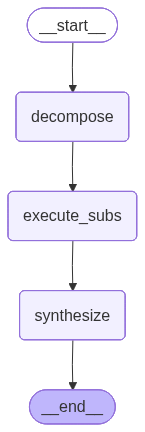

In [38]:
# Decomposition 그래프
decomp_graph = StateGraph(DecompState)

decomp_graph.add_node("decompose", decompose_question)
decomp_graph.add_node("execute_subs", execute_sub_questions)
decomp_graph.add_node("synthesize", synthesize_results)

decomp_graph.add_edge(START, "decompose")
decomp_graph.add_edge("decompose", "execute_subs")
decomp_graph.add_edge("execute_subs", "synthesize")
decomp_graph.add_edge("synthesize", END)

decomp_chain = decomp_graph.compile()

display(Image(decomp_chain.get_graph().draw_mermaid_png()))

### 3.3 Decomposition 파이프라인 테스트

In [39]:
# 테스트 1: 비교(compare) 질문
print("=" * 60)
print("테스트 1: 비교(compare) 질문")
print("=" * 60)
result = decomp_chain.invoke({
    "question": "삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요"
})
print(f"\n최종 답변:\n{result['answer']}")

테스트 1: 비교(compare) 질문
  복잡한 질문 -> 4개 서브 질문으로 분해
  전략: compare
     1. 삼성자산운용이 운용하는 ETF의 총 개수는?
     2. 삼성자산운용이 운용하는 ETF의 평균 수익률은?
     3. 미래에셋자산운용이 운용하는 ETF의 총 개수는?
     4. 미래에셋자산운용이 운용하는 ETF의 평균 수익률은?

  서브 질문 1: 삼성자산운용이 운용하는 ETF의 총 개수는?
     SQL: SELECT COUNT(*) AS 총개수 FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(202,)]

  서브 질문 2: 삼성자산운용이 운용하는 ETF의 평균 수익률은?
     SQL: SELECT AVG(수익률_최근1년) AS 평균_수익률 FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(6.585792079207921,)]

  서브 질문 3: 미래에셋자산운용이 운용하는 ETF의 총 개수는?
     SQL: SELECT COUNT(*) FROM ETFs WHERE 운용사 = '미래에셋자산운용'
     결과: [(200,)]

  서브 질문 4: 미래에셋자산운용이 운용하는 ETF의 평균 수익률은?
     SQL: SELECT AVG(수익률_최근1년) AS 평균_수익률 FROM ETFs WHERE 운용사 = '미래에셋자산운용'
     결과: [(7.3618,)]

최종 답변:
삼성자산운용과 미래에셋자산운용이 각각 운용하는 ETF의 수와 평균 최근 1년 수익률을 비교하면 다음과 같습니다.

1. **ETF 운용 개수**  
- 삼성자산운용: 202개  
- 미래에셋자산운용: 200개  

삼성자산운용이 미래에셋자산운용보다 운용하는 ETF 수가 약간 더 많습니다(2개 차이).

2. **ETF 평균 최근 1년 수익률**  
- 삼성자산운용: 약 6.59%  
- 미래에셋자산운용: 약 7.36%  

평균 수익률 측면에서는 미래에셋자산운용이 삼성자산운용보다 약 0.7

In [40]:
# 테스트 2: 순차(sequential) 질문
print("=" * 60)
print("테스트 2: 순차(sequential) 질문")
print("=" * 60)
result = decomp_chain.invoke({
    "question": "총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?"
})
print(f"\n최종 답변:\n{result['answer']}")

테스트 2: 순차(sequential) 질문
  복잡한 질문 -> 2개 서브 질문으로 분해
  전략: sequential
     1. 총보수가 가장 낮은 운용사는 어디인가?
     2. 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는 무엇인가?

  서브 질문 1: 총보수가 가장 낮은 운용사는 어디인가?
     SQL: SELECT 운용사, MIN(총보수) AS 최소_총보수 FROM ETFs GROUP BY 운용사 ORDER BY 최소_총보수 ASC LIMIT 10
     결과: [('한국투자신탁운용', 0.0), ('미래에셋자산운용', 0.008), ('삼성자산운용', 0.008), ('케이비자산운용', 0.008), ('키움투자자산운용', 0.009), ('한화자산운용', 0.009), 

  서브 질문 2: 총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는 무엇인가?
     SQL: SELECT 종목명, 운용사, 수익률_최근1년, 총보수 FROM ETFs WHERE 총보수 = (SELECT MIN(총보수) FROM ETFs) ORDER BY 수익률_최근1년 D
     결과: [('ACE 러시아MSCI(합성)', '한국투자신탁운용', -9.07, 0.0)]

최종 답변:
총보수가 가장 낮은 운용사는 '한국투자신탁운용'으로, 이 운용사의 총보수는 0.0%로 확인되었습니다. 

그런데, '한국투자신탁운용'의 총보수가 0.0%인 ETF 중 수익률 상위 3개를 조회한 결과, 해당 조건을 만족하는 ETF는 단 한 개, 즉 'ACE 러시아MSCI(합성)' 뿐이며, 이 ETF의 최근 1년 수익률은 -9.07%로 나타났습니다. 

따라서, 총보수가 가장 낮은 운용사의 ETF 중에서 수익률 상위 3개를 선정하는 것은 불가능하며, 현재 데이터상으로는 총보수가 가장 낮은 ETF 한 개가 수익률 기준으로 상위권입니다.  

정리하면,  
- 총보수가 가장 낮은 운용사: 한국투자신탁운용 (총보수 0.0%)  
- 해당 운용사의 총보수 0.0% ETF

In [41]:
# 테스트 3: 단순 질문 (분해 불필요)
print("=" * 60)
print("테스트 3: 단순 질문 (분해 불필요)")
print("=" * 60)
result = decomp_chain.invoke({"question": "ETF 총 개수는?"})
print(f"\n최종 답변:\n{result['answer']}")

테스트 3: 단순 질문 (분해 불필요)
  단순 질문 -> 분해 없이 처리

  서브 질문 1: ETF 총 개수는?
     SQL: SELECT COUNT(*) AS 총개수 FROM ETFs
     결과: [(930,)]

최종 답변:
현재 데이터베이스에서 확인된 ETF 총 개수는 930개입니다. 이는 ETF 데이터를 저장하고 있는 테이블(ETFs)에서 전체 레코드 수를 집계한 결과입니다. 따라서, 현재까지 등록된 또는 관리 중인 ETF 상품의 총 수는 930개임을 알 수 있습니다.


---

## 4. Decomposition vs 단일 SQL 비교

분해 기법의 효과를 확인하기 위해 동일한 복잡 질문에 대해  
기본 Chain(단일 SQL)과 Decomposition Chain의 결과를 비교합니다.

In [42]:
# 비교 테스트
comparison_questions = [
    "삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요",
    "총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?",
    "순자산총액 상위 10개 ETF의 운용사별 분포와 각 운용사의 평균 총보수는?",
]

for q in comparison_questions:
    print("=" * 70)
    print(f"Q: {q}")
    print("=" * 70)
    
    # 기본 Chain (단일 SQL)
    print("\n[기본 Chain - 단일 SQL]")
    basic_result = basic_chain.invoke({"question": q})
    print(f"  SQL: {basic_result['query'][:120]}")
    print(f"  답변: {basic_result['answer']}")
    
    # Decomposition Chain
    print("\n[Decomposition Chain]")
    decomp_result = decomp_chain.invoke({"question": q})
    print(f"  서브 질문 수: {len(decomp_result.get('sub_results', []))}")
    for sr in decomp_result.get("sub_results", []):
        print(f"    - {sr['question'][:60]}")
        print(f"      SQL: {sr['sql'][:100]}")
    print(f"  답변: {decomp_result['answer']}")
    print()

Q: 삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률을 비교해주세요

[기본 Chain - 단일 SQL]
  SQL: SELECT 운용사, COUNT(*) AS ETF_수, AVG(수익률_최근1년) AS 평균_수익률 FROM ETFs WHERE 운용사 IN ('삼성자산운용', '미래에셋자산운용') GROUP BY 운용사 ORDER 
  답변: 삼성자산운용과 미래에셋자산운용의 ETF 수와 평균 수익률 비교는 다음과 같습니다:

- 미래에셋자산운용: ETF 수 200개, 평균 수익률 약 7.36%
- 삼성자산운용: ETF 수 202개, 평균 수익률 약 6.59%

즉, 삼성자산운용이 ETF 수는 약간 더 많지만, 평균 수익률은 미래에셋자산운용이 더 높은 상태입니다.

[Decomposition Chain]
  복잡한 질문 -> 4개 서브 질문으로 분해
  전략: compare
     1. 삼성자산운용이 운용하는 ETF의 수는?
     2. 삼성자산운용이 운용하는 ETF의 평균 수익률은?
     3. 미래에셋자산운용이 운용하는 ETF의 수는?
     4. 미래에셋자산운용이 운용하는 ETF의 평균 수익률은?

  서브 질문 1: 삼성자산운용이 운용하는 ETF의 수는?
     SQL: SELECT COUNT(*) FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(202,)]

  서브 질문 2: 삼성자산운용이 운용하는 ETF의 평균 수익률은?
     SQL: SELECT AVG(수익률_최근1년) AS 평균_수익률 FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(6.585792079207921,)]

  서브 질문 3: 미래에셋자산운용이 운용하는 ETF의 수는?
     SQL: SELECT COUNT(*) AS cnt FROM ETFs WHERE 운용사 = '미래에셋자산운용'
     결과: [(200,)]

  서브 질문 4: 미래에셋자산운용이 운용하는 ETF의 평균 수익률은?
     SQL: 

---

## 5. 통합 파이프라인 - 조건부 라우팅

실제 서비스에서는 모든 질문을 분해할 필요가 없습니다.  
**질문 복잡도에 따라 자동으로 경로를 선택**하는 통합 파이프라인을 구축합니다.

```
사용자 질문
    │
    ▼
[복잡도 분석]
    │
    ├── 단순 → [Few-Shot SQL 생성] → [실행] → [답변 생성]
    │
    └── 복잡 → [서브 질문 분해] → [각각 실행] → [결과 종합]
```

In [43]:
def route_by_complexity(state: DecompState) -> str:
    """복잡도에 따라 처리 경로 선택"""
    if state.get("is_complex", False):
        return "execute_subs"
    return "simple_query"

def simple_query(state: DecompState):
    """단순 질문: Few-Shot SQL 생성 + 실행"""
    similar_docs = example_retriever.invoke(state["question"])
    formatted = format_examples(similar_docs)
    
    prompt = fewshot_prompt_template.invoke({
        "dialect": db.dialect,
        "top_k": 10,
        "table_info": db.get_table_info(),
        "entity_info": entity_retriever_tool.invoke(state["question"]),
        "examples": formatted,
        "input": state["question"],
    })
    structured_llm = llm.with_structured_output(QueryOutput, method="function_calling")
    query_result = structured_llm.invoke(prompt)
    
    tool = QuerySQLDatabaseTool(db=db)
    try:
        result = tool.invoke(query_result.query)
    except Exception as e:
        result = f"오류: {str(e)}"
    
    return {"query": query_result.query, "result": result}

def generate_simple_answer(state: DecompState):
    """단순 질문 답변 생성"""
    prompt = (
        "Given the following user question, corresponding SQL query, "
        "and SQL result, answer the user question.\n\n"
        f'Question: {state["question"]}\n'
        f'SQL Query: {state["query"]}\n'
        f'SQL Result: {state["result"]}'
    )
    response = llm.invoke(prompt)
    return {"answer": response.content}

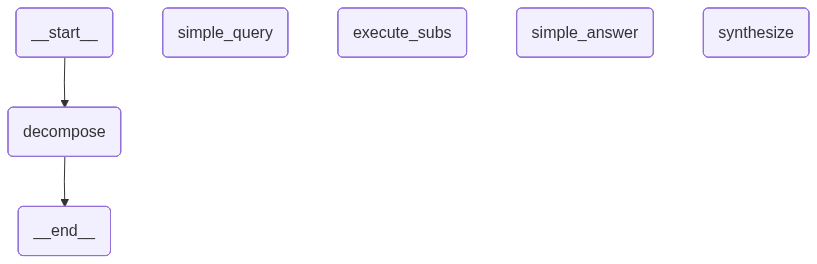

In [44]:
# 통합 그래프
integrated_graph = StateGraph(DecompState)

integrated_graph.add_node("decompose", decompose_question)
integrated_graph.add_node("simple_query", simple_query)
integrated_graph.add_node("execute_subs", execute_sub_questions)
integrated_graph.add_node("simple_answer", generate_simple_answer)
integrated_graph.add_node("synthesize", synthesize_results)

# 엣지 연결
integrated_graph.add_edge(START, "decompose")
integrated_graph.add_conditional_edges("decompose", route_by_complexity)
integrated_graph.add_edge("simple_query", "simple_answer")
integrated_graph.add_edge("execute_subs", "synthesize")
integrated_graph.add_edge("simple_answer", END)
integrated_graph.add_edge("synthesize", END)

integrated_chain = integrated_graph.compile()

display(Image(integrated_chain.get_graph().draw_mermaid_png()))

In [45]:
# 통합 파이프라인 테스트
test_cases = [
    ("단순", "총보수가 0.1% 이하인 ETF 목록을 보여주세요"),
    ("비교", "삼성자산운용과 미래에셋자산운용의 평균 총보수와 ETF 수를 비교해주세요"),
    ("순차", "순자산총액 상위 10개 ETF의 운용사별 분포와 각 운용사의 평균 총보수는?"),
]

for label, q in test_cases:
    print("=" * 60)
    print(f"[{label}] {q}")
    print("=" * 60)
    result = integrated_chain.invoke({"question": q})
    print(f"\n답변:\n{result['answer']}")
    print()

[단순] 총보수가 0.1% 이하인 ETF 목록을 보여주세요
  단순 질문 -> 분해 없이 처리

답변:
총보수가 0.1% 이하인 ETF 목록은 다음과 같습니다:

1. ACE 러시아MSCI(합성) - 0.0%
2. KODEX 코리아밸류업 - 0.008%
3. RISE 코리아밸류업 - 0.008%
4. TIGER 코리아밸류업 - 0.008%
5. KODEX 미국S&P500(H) - 0.009%
6. KODEX 미국S&P500TR - 0.009%
7. KODEX 미국나스닥100(H) - 0.009%
8. KODEX 미국나스닥100TR - 0.009%
9. KODEX 미국배당다우존스 - 0.009%
10. KOSEF 코리아밸류업 - 0.009%

[비교] 삼성자산운용과 미래에셋자산운용의 평균 총보수와 ETF 수를 비교해주세요
  복잡한 질문 -> 4개 서브 질문으로 분해
  전략: compare
     1. 삼성자산운용의 평균 총보수는?
     2. 삼성자산운용의 ETF 수는?
     3. 미래에셋자산운용의 평균 총보수는?
     4. 미래에셋자산운용의 ETF 수는?

  서브 질문 1: 삼성자산운용의 평균 총보수는?
     SQL: SELECT AVG(총보수) AS avg_fee FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(0.2771138613861386,)]

  서브 질문 2: 삼성자산운용의 ETF 수는?
     SQL: SELECT COUNT(*) as ETF_count FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(202,)]

  서브 질문 3: 미래에셋자산운용의 평균 총보수는?
     SQL: SELECT AVG(총보수) AS avg_fee FROM ETFs WHERE 운용사 = '미래에셋자산운용'
     결과: [(0.343105,)]

  서브 질문 4: 미래에셋자산운용의 ETF 수는?
     SQL: SELECT COUNT(*) as ETF_수 FROM ETFs WHERE

In [46]:
# 통합 파이프라인 테스트
test_cases = [
    ("단순", "총보수가 0.1% 이하인 ETF 목록을 보여주세요"),
    ("비교", "삼성자산운용과 미래에셋자산운용의 평균 총보수와 ETF 수를 비교해주세요"),
    ("순차", "순자산총액 상위 10개 ETF의 운용사별 분포와 각 운용사의 평균 총보수는?"),
]

for label, q in test_cases:
    print("=" * 60)
    print(f"[{label}] {q}")
    print("=" * 60)
    result = integrated_chain.invoke({"question": q})
    print(f"\n답변:\n{result['answer']}")
    print()

[단순] 총보수가 0.1% 이하인 ETF 목록을 보여주세요
  단순 질문 -> 분해 없이 처리

답변:
총보수가 0.1% 이하인 ETF 목록은 다음과 같습니다:

1. ACE 러시아MSCI(합성) - 0.0%
2. KODEX 코리아밸류업 - 0.008%
3. RISE 코리아밸류업 - 0.008%
4. TIGER 코리아밸류업 - 0.008%
5. KODEX 미국S&P500(H) - 0.009%
6. KODEX 미국S&P500TR - 0.009%
7. KODEX 미국나스닥100(H) - 0.009%
8. KODEX 미국나스닥100TR - 0.009%
9. KODEX 미국배당다우존스 - 0.009%
10. KOSEF 코리아밸류업 - 0.009%

[비교] 삼성자산운용과 미래에셋자산운용의 평균 총보수와 ETF 수를 비교해주세요
  복잡한 질문 -> 4개 서브 질문으로 분해
  전략: compare
     1. 삼성자산운용의 평균 총보수는 얼마인가?
     2. 삼성자산운용의 ETF 수는 몇 개인가?
     3. 미래에셋자산운용의 평균 총보수는 얼마인가?
     4. 미래에셋자산운용의 ETF 수는 몇 개인가?

  서브 질문 1: 삼성자산운용의 평균 총보수는 얼마인가?
     SQL: SELECT AVG(총보수) AS 평균_총보수 FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(0.2771138613861386,)]

  서브 질문 2: 삼성자산운용의 ETF 수는 몇 개인가?
     SQL: SELECT COUNT(*) FROM ETFs WHERE 운용사 = '삼성자산운용'
     결과: [(202,)]

  서브 질문 3: 미래에셋자산운용의 평균 총보수는 얼마인가?
     SQL: SELECT AVG(총보수) AS avg_total_fee FROM ETFs WHERE 운용사 = '미래에셋자산운용'
     결과: [(0.343105,)]

  서브 질문 4: 미래에셋자산운용의 ETF 수는 몇 개인가?
     SQL: SELE

---

## [실습] Sequential Decomposition 개선

### 문제
현재 `sequential` 전략에서는 서브 질문들이 독립적으로 실행됩니다.  
하지만 진정한 sequential은 **이전 서브 질문의 결과를 다음 서브 질문의 조건에 반영**해야 합니다.

예: "총보수가 가장 낮은 운용사의 ETF 중 수익률 상위 3개는?"
1. 서브 1: "총보수가 가장 낮은 운용사는?" → 결과: "XX자산운용"
2. 서브 2: "XX자산운용의 ETF 중 수익률 상위 3개는?" (서브 1 결과 반영!)

### 구현 단계
1. `execute_sub_questions` 함수를 수정하여 `sequential` 전략일 때 이전 결과를 다음 질문에 반영
2. 이전 서브 질문의 실행 결과를 현재 서브 질문의 컨텍스트로 추가
3. 수정된 파이프라인으로 sequential 질문 테스트

### 힌트
```python
if state["aggregation_strategy"] == "sequential" and i > 0:
    # 이전 결과를 현재 서브 질문에 반영
    prev_result = sub_results[i-1]["result"]
    sq = f"{sq}\n(참고: 이전 단계 결과 = {prev_result})"
```

In [ ]:
# 여기에 코드를 작성하세요.


: 